In [ ]:
                                                                        (1e-3, 100)*396.7+[1.09317e-01 :  3.12285e+08]
2.53009e-01 :  1.56163e+08    z33     mc::FFVar avgConcConc = 0.5 * (concOutConcentrateNd * scaleFacConc + concInED);
2.53009e-01 :  1.56163e+08    z36    mc::FFVar avgConcDil = 0.5 * (concOutDiluteNd * scaleFacConc + concInED);




In [ ]:
[  3.78501e-09 :  2.33619e+04 ] v100 z125.  resConcentrate * conducConcentrate * avgConcConc 
                                            [  1.49600e-08 :  1.49600e-04 ] * [  2.53009e-01 :  1.56163e+08 ]

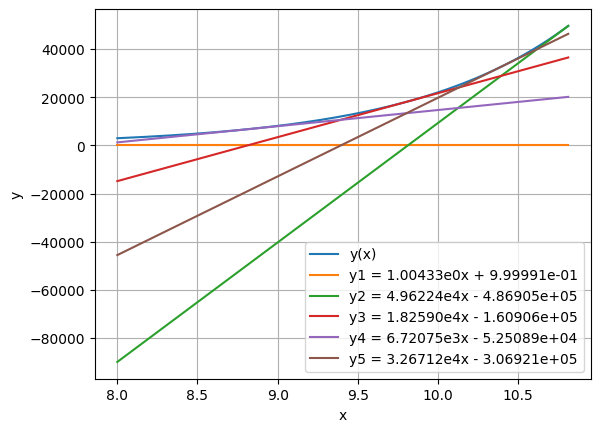

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(4.32488e-03 ,  1.08122e+01, 400)   # range of x values

x = np.linspace(8 ,  1.08122e+01, 400)   # range of x values
y=np.exp(x)


y1 = 1.00433e+00*(x) + 9.99991e-01
y2=4.96224e+04*(x) -4.86905e+05
y3=1.82590e+04*(x) -1.60906e+05
y4=6.72075e+03*(x) -5.25089e+04
y5=3.26712e+04*(x) -3.06921e+05
plt.plot(x, y, label='y(x)')
plt.plot(x, y1, label='y1 = 1.00433e0x + 9.99991e-01')
plt.plot(x, y2, label='y2 = 4.96224e4x - 4.86905e+05')
plt.plot(x, y3, label='y3 = 1.82590e4x - 1.60906e+05')
plt.plot(x, y4, label='y4 = 6.72075e3x - 5.25089e+04')
plt.plot(x, y5, label='y5 = 3.26712e4x - 3.06921e+05')
plt.xlabel('x')
plt.ylabel('y')

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
def wireframe_trace(X, Y, Z, color='blue', name='', step=10):
    """Build wireframe lines (along x and y directions) for a surface."""
    lines = []
    # lines along y-direction (constant x rows)
    for i in range(0, X.shape[0], step):
        lines.append(go.Scatter3d(
            x=X[i, :], y=Y[i, :], z=Z[i, :],
            mode='lines', line=dict(color=color, width=2),
            name=name, showlegend=False
        ))
    # lines along x-direction (constant y columns)
    for j in range(0, X.shape[1], step):
        lines.append(go.Scatter3d(
            x=X[:, j], y=Y[:, j], z=Z[:, j],
            mode='lines', line=dict(color=color, width=2),
            name=name, showlegend=False
        ))
    return lines



x = np.linspace(2.53009e-01,  1.56163e+08, 100) #v105
y = np.linspace(1.00433e+00 ,  4.96224e+04, 100) #v112 z136 exp()

X, Y = np.meshgrid(x, y)
#  + 1.00000e+00V113 - 1.00433e+00V105 - 1.56163e+08V112 <= -1.56839e+08
#   + 1.00000e+00V113 - 4.96224e+04V105 - 2.53009e-01V112 <= -1.25549e+04
#   + 1.00000e+00V113 - 4.96224e+04V105 - 1.56163e+08V112 >= -7.74916e+12
#   + 1.00000e+00V113 - 1.00433e+00V105 - 2.53009e-01V112 >= -2.54105e-01
# addEqualityConstraint(exp(voltNonOhmicCem * faraday / (permSelCem * rg * temp)) * avgConcDil - avgConcConc);


Z = X * Y
z1=4.96224e+04*X+1.56163e+08*Y-7.74916e+12
z2=1.00433e+00*X+2.53009e-01*Y-2.54105e-01

fig = go.Figure()
for trace in wireframe_trace(X, Y, Z, color='red', name='z', step=10):
    fig.add_trace(trace)
for trace in wireframe_trace(X, Y, z1, color='blue', name='z1', step=10):
    fig.add_trace(trace)
for trace in wireframe_trace(X, Y, z2, color='green', name='z2', step=10):
    fig.add_trace(trace)

fig.update_layout(
    title='Multiple wireframe surfaces',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=800, height=600
)
fig.show()

In [ ]:
z9 concInED
z36 avgConcDil [  2.53009e-01 :  1.56163e+08 ]
z136 exp() [  1.00433e+00 :  4.96224e+04 ]
z137 = z36 * z136

flowOutDiluteNd * (scaleFacFlow * numCells) * concOutDiluteNd * scaleFacConc

In [ ]:
z4 v94 deminator. 3.20220e-02 :  9.14771e+03
z8 v91 numeriaot
z9 v95 ratio. 1.09317e-01 :  3.12285e+08
z6 v122

In [1]:

import numpy as np
import plotly.graph_objects as go
 
# --- bounds ---
j_lo, j_hi = 10.0, 1.0e4      # currentDensity
V_lo, V_hi = 0.0, 5.0         # voltCellPair
w_lo, w_hi = 1e-2, 10.0       # memWidth
 
# finer grid; log-spaced on currentDensity since it spans 3 decades
n = 35
x = np.logspace(np.log10(j_lo), np.log10(j_hi), n)   # currentDensity
y = np.linspace(V_lo, V_hi, n)                        # voltCellPair
z = np.linspace(w_lo, w_hi, n)                        # memWidth
 
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
 
costElec = 0.08147
resBlank = 2.5e-5
numCells = 500.0
daysOperation = 7.0 * 365.0
c1 = costElec * 24e-3 * resBlank * daysOperation
c2 = costElec * 24e-3 * numCells * daysOperation
 
def f(x, y, z):
    return c1 * x**2 * z**2 + c2 * y * x * z**2
 
# evaluate on the FULL 3D grid, not the 1D vectors
values = f(X, Y, Z)
 
# log10 transform -- the raw function spans ~16 orders of magnitude
logvals = np.log10(values)
print("log10(value) range:", logvals.min(), "to", logvals.max())
 
fig = go.Figure(data=go.Isosurface(
    x=X.flatten(), y=Y.flatten(), z=Z.flatten(),
    value=logvals.flatten(),
    isomin=0,
    isomax=logvals.min() + 0.85*(logvals.max()-logvals.min()),
    surface_count=5,
    colorscale='Viridis',
    caps=dict(x_show=False, y_show=False, z_show=False),
    opacity=0.5,
    colorbar=dict(title="log10(expr)")
))
 
fig.update_layout(
    scene=dict(
        xaxis=dict(title='currentDensity (j)', type='log'),
        yaxis_title='voltCellPair (V)',
        zaxis_title='memWidth (w)',
    ),
    title="opex1 expression -- log10 isosurfaces over the decision-variable box",
    margin=dict(l=0, r=0, t=40, b=0)
)

log10(value) range: -5.903460128834982 to 10.09658329844188


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
def wireframe_trace(X, Y, Z, color='blue', name='', step=5):
    """Build wireframe lines (along x and y directions) for a surface."""
    lines = []
    # lines along y-direction (constant x rows)
    for i in range(0, X.shape[0], step):
        lines.append(go.Scatter3d(
            x=X[i, :], y=Y[i, :], z=Z[i, :],
            mode='lines', line=dict(color=color, width=2),
            name=name, showlegend=False
        ))
    # lines along x-direction (constant y columns)
    for j in range(0, X.shape[1], step):
        lines.append(go.Scatter3d(
            x=X[:, j], y=Y[:, j], z=Z[:, j],
            mode='lines', line=dict(color=color, width=2),
            name=name, showlegend=False
        ))
    return lines

x = np.linspace(3.20220e-02 ,  9.14771e+03, 10) #v94
y = np.linspace(1.09317e-01 ,  3.12285e+08, 10) #v95
#. molNStream1 * densityH2OGm3 / (molNStream1 * molweightN + molWStream1 * molweightH20gMol);
#v91/v94=v95
X, Y = np.meshgrid(x, y)


Z = X * Y
z1=9.14771e+03*Y + 3.12285e+08*X  -2.85670e+12
z2=3.20220e-02*Y + 1.09317e-01*X  -3.50055e-03

fig = go.Figure()
for trace in wireframe_trace(X, Y, Z, color='black', name='z = x·y', step=3):
    fig.add_trace(trace)

for trace in wireframe_trace(X, Y, z1, color='orange', name='z = x·y', step=3):
    fig.add_trace(trace)
for trace in wireframe_trace(X, Y, z2, color='crimson', name='z = x²−y²', step=3):
    fig.add_trace(trace)


fig.update_layout(
    title='Multiple wireframe surfaces',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=800, height=600
)
fig.show()
